In [ ]:
# 1. Load & Inspect Data

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [5]:
# Load cleaned dataset
df = pd.read_csv("D:/DATA ANALYTICS/Real-Time UPI Fraud Detection & Risk Analytics System/fraud_dataset.csv")

In [6]:
# 2.Basic inspection
df.head()

,transaction_id,user_id,merchant_id,amount,timestamp,description,device_id,ip_address,location,session_duration,...,handle_similarity_score,handle_contains_official_terms,handle_typo_analysis,handle_transaction_history,business_name_match,social_media_presence,handle_registration_pattern,handle_to_description_consistency,handle_verification_status,is_fraud
0,7d4e9561-000c-44c8-84e4-54af2c4ac209,michelle89,8bdff36c-efba-4260-a801-8bd36f0f2eb0,1960.754748,18:27.7,Payment to Lee-Warren for products,0c51ef4f-41a8-41da-b721-b74a8055dc4c,49.221.248.16,"(14.5837385, 85.305345)",234,...,0.0,0,none,0,none,none,none,0,verified,0
1,fbf88cde-dc62-4f36-ac10-a1b1fd771793,eguerrero,a28f2b48-5423-4eb6-9018-00e6e55410af,4593.854621,34:55.5,"Payment to Wright, Johnson and Parker for prod...",932aab8b-af95-4214-b555-7f5f2d67308c,106.79.40.40,"(-41.063726, -164.178102)",98,...,0.0,0,none,0,none,none,none,0,verified,0
2,d746c963-baaa-46a0-80f4-b050e14e1c7d,alexanderpatrick,ce4ed336-6b99-42f2-88ca-dba320b8a96f,1949.587163,49:42.8,Payment to Hanson Ltd for products,0dc46fa1-fb1f-4bc6-9e03-af19e1c46e1b,125.165.248.30,"(52.1582705, -162.522989)",100,...,0.0,0,none,0,none,none,none,0,verified,0
3,e5f8a1cc-4bf6-46d2-b9b2-aa393ff4e244,timothy32,3a6129b8-6cdd-4c5a-9bf5-a312da5a9fd3,2825.569899,16:29.9,"Payment to Garcia, Barron and Wood for services",2cc9e843-b5b2-41cf-a6db-aa7fc659986a,89.223.179.179,"(48.549751, -163.02585)",145,...,0.0,0,none,0,none,none,none,0,verified,0
4,34309820-3aec-4fa4-9518-03437830e1e0,billycalhoun,2e34ad70-ec10-4ac1-895e-2773c6246f62,6509.628443,39:44.7,Payment via link: http://lowe.com/search/wp-co...,b503c1d9-fd00-4289-93b9-e297c98f0228,156.93.45.217,"(-61.0860645, 18.331554)",13,...,0.0,0,none,0,none,none,none,0,unverified,1


In [8]:
# Basic inspection
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 26393 entries, 0 to 26392
Data columns (total 65 columns):
 #   Column                                   Non-Null Count  Dtype  
---  ------                                   --------------  -----  
 0   transaction_id                           26393 non-null  object 
 1   user_id                                  26393 non-null  object 
 2   merchant_id                              26393 non-null  object 
 3   amount                                   26393 non-null  float64
 4   timestamp                                26393 non-null  object 
 5   description                              26393 non-null  object 
 6   device_id                                26393 non-null  object 
 7   ip_address                               26393 non-null  object 
 8   location                                 26393 non-null  object 
 9   session_duration                         26393 non-null  int64  
 10  authentication_attempts                  26393

,amount,session_duration,authentication_attempts,receiver_account_age,receiver_transaction_history,transaction_amount_vs_sender_history,geographic_disparity,transaction_time_of_day,time_between_link_click_and_transaction,unusual_device_flag,...,request_acceptance_rate,time_to_respond_to_request,time_pressure_indicators,requester_account_age,upi_handle_age,handle_similarity_score,handle_contains_official_terms,handle_transaction_history,handle_to_description_consistency,is_fraud
count,26393.000000,26393.000000,26393.000000,26393.000000,26393.000000,26393.000000,26393.000000,26393.000000,26393.000000,26393.000000,...,26393.000000,26393.000000,26393.000000,26393.000000,26393.0,26393.000000,26393.0,26393.000000,26393.000000,26393.000000
mean,4865.367115,161.625014,1.108589,150.288486,42.332588,3.037531,10005.354810,11.007426,0.499754,0.056454,...,0.005539,0.479938,0.195052,0.098435,0.0,0.006566,0.0,0.073163,0.028303,0.172205
std,5720.508492,89.453321,0.543179,161.297565,31.559755,7.609687,4712.004930,7.071321,3.183178,0.230801,...,0.034060,3.098854,0.728742,0.696858,0.0,0.059918,0.0,0.515511,0.165840,0.377565
min,139.267664,5.000000,1.000000,0.000000,0.000000,0.222799,14.167439,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.0,0.000000,0.0,0.000000,0.000000,0.000000
25%,2425.484162,88.000000,1.000000,13.000000,11.000000,0.955017,6307.037068,5.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.0,0.000000,0.0,0.000000,0.000000,0.000000
50%,3685.574962,156.000000,1.000000,96.000000,40.000000,1.513964,10008.865710,10.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.0,0.000000,0.0,0.000000,0.000000,0.000000
75%,5239.994313,231.000000,1.000000,240.000000,70.000000,2.623680,13708.758450,17.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.0,0.000000,0.0,0.000000,0.000000,0.000000
max,49970.158580,600.000000,5.000000,723.000000,100.000000,294.628680,19983.477890,23.000000,30.000000,1.000000,...,0.299788,30.000000,5.000000,7.000000,0.0,0.600000,0.0,5.000000,1.000000,1.000000


In [18]:
# 3.CHECK NULL VALUES
df.isnull().sum()

transaction_id                       0
user_id                              0
merchant_id                          0
amount                               0
timestamp                            0
                                    ..
social_media_presence                0
handle_registration_pattern          0
handle_to_description_consistency    0
handle_verification_status           0
is_fraud                             0
Length: 65, dtype: int64

In [19]:
# 4.CLEANING DATA 

df.fillna(0, inplace=True)

In [20]:
# 5.CLEANING DATA 

df.drop_duplicates(inplace=True)

In [22]:
# 6.CHECK FRAUD COUNTS

df['is_fraud'].value_counts()

is_fraud
0    21848
1     4545
Name: count, dtype: int64

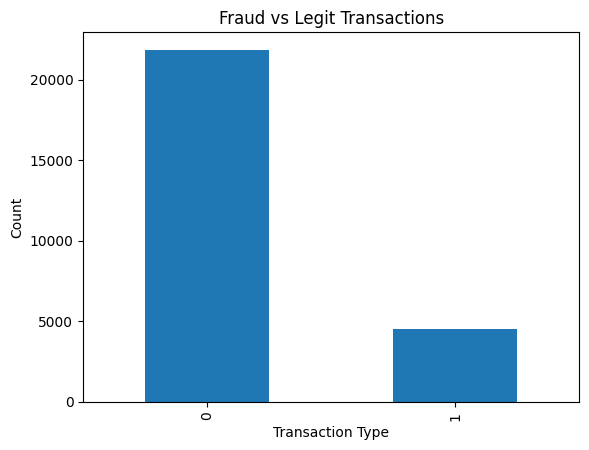

In [23]:
# 7.FRAUD DISTRIBUTION CHART

import matplotlib.pyplot as plt

df['is_fraud'].value_counts().plot(kind='bar')

plt.title("Fraud vs Legit Transactions")

plt.xlabel("Transaction Type")

plt.ylabel("Count")

plt.show()

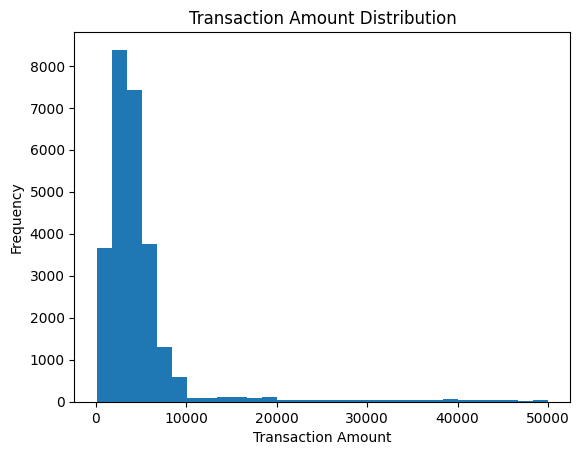

In [24]:
# 8.TRANSACTION AMOUNT HISTOGRAM

plt.hist(df['amount'], bins=30)

plt.title("Transaction Amount Distribution")

plt.xlabel("Transaction Amount")

plt.ylabel("Frequency")

plt.show()

In [28]:
# 9.FRAUD BY TRANSACTION TYPE 

fraud_by_type = df.groupby(
    'transaction_type'
)['is_fraud'].sum()

print(fraud_by_type)

transaction_type
collection_request     732
payment               3813
Name: is_fraud, dtype: int64


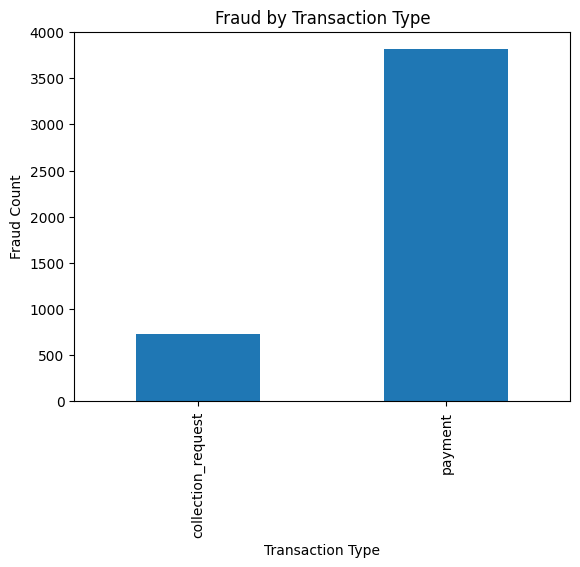

In [30]:
# 10.FRAUD TYPE CHART

fraud_by_type.plot(kind='bar')

plt.title("Fraud by Transaction Type")

plt.xlabel("Transaction Type")

plt.ylabel("Fraud Count")

plt.show()

In [31]:
# 11.ANOMALY DETECTION

from sklearn.ensemble import IsolationForest

model = IsolationForest(
    contamination=0.02,
    random_state=42
)

df['anomaly'] = model.fit_predict(
    df[['amount']]
)

In [32]:
# 12.VIEW SUSPICIOUS TRANSACTIONS

suspicious = df[df['anomaly'] == -1]

suspicious.head()

,transaction_id,user_id,merchant_id,amount,timestamp,description,device_id,ip_address,location,session_duration,...,handle_contains_official_terms,handle_typo_analysis,handle_transaction_history,business_name_match,social_media_presence,handle_registration_pattern,handle_to_description_consistency,handle_verification_status,is_fraud,anomaly
110,de54c8a9-4bfb-42e0-973e-b64dece128eb,sheila86,19107c8d-f750-4ff7-b090-4c885ed6ef1f,37482.59826,03:40.1,Payment to Paytm_clone for premium products,7c0a3461-f5dc-4c68-9a65-1b8c1a1808a0,3.155.227.121,"(-85.158965, 46.209209)",236,...,0,none,0,none,none,recent,0,unverified,1,-1
158,40b65b1a-6daf-486b-8e25-758e705140b1,gmarshall,b4c6a617-4d2d-4050-b6e5-5ed9cf7c366e,49146.97023,44:04.6,Payment to Snapdeal_clone for premium products,8b50cfeb-6bb0-4d26-9af9-defb0ba2b9d8,212.251.216.97,"(49.5169695, 86.991916)",294,...,0,none,0,none,none,recent,0,unverified,1,-1
278,0c274fad-bf5f-4ad3-90d3-3a7b64d3b14c,hillsabrina,72266c00-c5ab-4014-b645-122f226b26eb,27708.37172,57:21.2,Payment to Amazon_clone for premium products,b0fb8427-b0a3-4a3e-910d-4d6692cfa6f5,72.6.118.61,"(56.162794, 35.856962)",270,...,0,none,0,none,none,recent,0,unverified,1,-1
406,0cc8042b-0492-437d-a9b6-c3f14319ad76,dennissmith,2a856e5d-58a6-4b1d-a956-08b7101dc1e4,32095.77469,55:43.7,Payment to Paytm_clone for premium products,93c24885-a01e-4068-bc13-45e625525ed0,37.122.221.66,"(73.1810895, 40.122315)",57,...,0,none,0,none,none,recent,0,unverified,1,-1
474,d8154ff5-7322-4960-8944-1a7a6251762a,joan49,15fbb8a0-716d-41ef-a335-42b2b74d4a6e,36418.13555,20:00.9,Payment to Paytm_clone for premium products,80b01b83-3659-4875-9999-475c7b4003d2,163.82.7.132,"(-5.9791945, -40.0264)",203,...,0,none,0,none,none,recent,0,unverified,1,-1


In [33]:
# 13.MACHINE LEARNING FEATURES 

features = [
    'amount',
    'unusual_device_flag',
    'unusual_ip_flag',
    'transaction_velocity',
    'failed_transaction_count',
    'otp_request_frequency'
]

In [34]:
# DEFINE X AND y

X = df[features]

y = df['is_fraud']

In [35]:
# TRAIN TEST SPLIT

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [36]:
# 14.LOGISTIC REGRESSION

from sklearn.linear_model import LogisticRegression

model = LogisticRegression(max_iter=1000)

model.fit(X_train, y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`mul

In [37]:
# 15.PREDICTIONS 

predictions = model.predict(X_test)

In [38]:
predictions[:10]

array([0, 0, 0, 0, 0, 0, 0, 1, 0, 0])

In [23]:
# 16.ACCURACY

from sklearn.metrics import accuracy_score

accuracy = accuracy_score(
    y_test,
    predictions
)

print("Accuracy:", accuracy)

Accuracy: 0.9473385110816442


In [39]:
# 17.CONFUSION MATRIX

from sklearn.metrics import confusion_matrix

confusion_matrix(
    y_test,
    predictions
)

array([[4351,    5],
       [ 273,  650]])

In [40]:
# SAVE FINAL DATASET
df.to_csv(
    "cleaned_fraud_data.csv",
    index=False
)